# mjo_cross_plot

### Example NCL Script and Output

- mjo_cross.ncl
- mjo_output/mjo_cross_output.txt

### Example Plot fom `mjo_cross.ncl`

- mjo_output/mjo_cross.png

<center>
<img src="mjo_output/mjo_cross.png" width="400" height="600">
</center>

In [77]:
import matplotlib.pyplot as plt
import numpy as np

In [92]:
# collect NCL data from mjo_output
mjo_cross_data = np.loadtxt("mjo_output/mjo_cross_output.txt", skiprows=26)
mjo_cross_data = mjo_cross_data.reshape(16, 129, 289) # [var | 16] x [freq | 129] x [wave | 289]
print(mjo_cross_data.shape)

(16, 129, 289)


In [72]:
# from mjo_cross_output.txt
prob_coh2 = [0.007943451, 0.02954906, 0.1019666, 0.1846326, 0.3290648, 0.8042979]
prob_days = [80, 20, 10, 5, 3, 1]
freq = [0, 0.5]

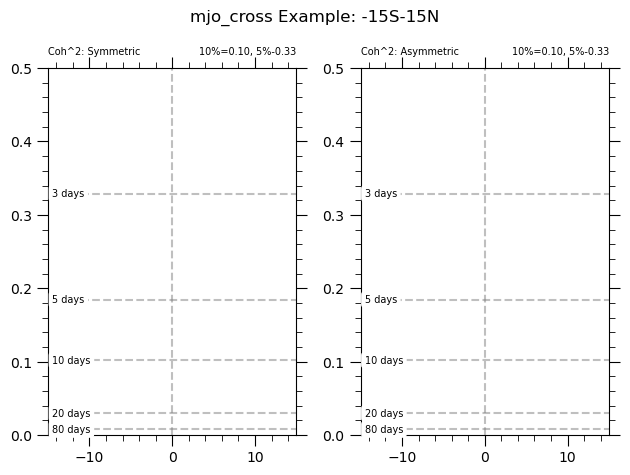

In [76]:
max_wave_plot = 15 # min/max wavenumber to plot on the x-axis (default = 15)
font_size = 7
major_length = 8
minor_length = 4
title_pad = 10

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

#ax1.semilogy(freqs, cps_mag)
ax1.set_xlim(-max_wave_plot, max_wave_plot)
ax1.set_ylim(freq[0], freq[1])
ax1.set_title("Coh^2: Symmetric", loc="left", fontsize=font_size, pad=title_pad)
ax1.set_title("10%=0.10, 5%-0.33", loc="right", fontsize=font_size, pad=title_pad)
ax1.tick_params(which="major", length=major_length, top=True, right=True, bottom=True, left=True)
ax1.tick_params(which="minor", length=minor_length, top=True, right=True)
ax1.minorticks_on()
ax1.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
for i, y_line in enumerate(prob_coh2):
    if y_line < freq[1]: # filter out options out of the range of freq
        ax1.axhline(y=y_line, color="grey", linestyle="--", alpha=0.5)
        # add days label with white box around text
        ax1.text(x=-max_wave_plot+0.5, y=y_line, s=f"{prob_days[i]} days",
                ha="left", va="center", fontsize=font_size,
                bbox=dict(facecolor="white", edgecolor="white", boxstyle='round'))

#ax2.plot(freqs, cps_phase)
ax2.set_xlim(-max_wave_plot, max_wave_plot)
ax2.set_ylim(freq[0], freq[1])
ax2.set_title("Coh^2: Asymmetric", loc="left", fontsize=font_size, pad=title_pad)
ax2.set_title("10%=0.10, 5%-0.33", loc="right", fontsize=font_size, pad=title_pad)
ax2.tick_params(which="major", length=major_length, top=True, right=True, bottom=True, left=True)
ax2.tick_params(which="minor", length=minor_length, top=True, right=True)
ax2.minorticks_on()
ax2.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
for i, y_line in enumerate(prob_coh2):
    if y_line < freq[1]: # filter out options out of the range of freq
        ax2.axhline(y=y_line, color="grey", linestyle="--", alpha=0.5)
        # add days label with white box around text
        ax2.text(x=-max_wave_plot+0.5, y=y_line, s=f"{prob_days[i]} days",
                ha="left", va="center", fontsize=font_size,
                bbox=dict(facecolor="white", edgecolor="white", boxstyle='round'))

plt.suptitle("mjo_cross Example: -15S-15N")
plt.tight_layout()
plt.show()